In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [50]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(404, 2) (404, 1)
(102, 2) (102, 1)


In [51]:
X_train

,LSTAT,RM
165,9.81,6.101
263,11.25,7.327
208,14.66,6.064
69,8.79,5.885
154,15.12,6.129
...,...,...
386,28.28,4.652
372,8.88,5.875
176,10.11,6.020
333,5.68,6.316


In [192]:
#now we have the train and test set
#we have to find the optimal values for w and b that minimizes the cost fuction
#using gradient descent we will try to find those values
def update_w_and_b(x, y, w, b, alpha, s_1, s_2, epsilon, beta):
    dl_dw = 0
    dl_db = 0
    N = len(x)
    s1, s2 = s_1, s_2
    for i in range(N):
        dl_dw += -2*x[i]*(y[i] - (w*x[i] +b))
        dl_db += -2*(y[i] - (w*x[i] + b))  
    s1 = (beta * s1) + ((1 - beta) * (np.square(1/float(N) * dl_dw)))
    s2 = (beta * s2) + ((1 - beta) * (np.square(1/float(N) * dl_dw)))
    #w = w - (alpha * ((((1/float(N))*dl_dw)) / np.sqrt(s1+epsilon)))
    #b = b - (alpha * ((((1/float(N))*dl_db)) / np.sqrt(s2+epsilon)))
    
    #w = w - ((alpha * (1/float(N) * dl_dw)) / (np.sqrt(s1+epsilon)))
    #b = b - ((alpha * (1/float(N) * dl_db)) / (np.sqrt(s2+epsilon)))
    w = w - ((alpha * (dl_dw)) / (np.sqrt(s1+epsilon)))
    b = b - ((alpha * (dl_db)) / (np.sqrt(s2+epsilon)))
    return w, b, s1, s2

In [193]:
from matplotlib.pyplot import figure
def train(x, y, w, b, alpha, epochs):
    """this function searches for the best value for the parameters w and b,
    it takes x, y, w and b where w and b both are initially 0,
    the function loops the training set 
    """
    avg_loss_list = []
    w_list = []
    b_list = []
    img_list = []
    pred_val_at_diff_epoch = []
    s_1, s_2 = 0, 0
    epsilon = 0.00000000001
    beta = 0.9
    for num_of_epochs in range(epochs):
        xy = pd.concat([x, y], axis = 1)
        indexes = xy.index
        rand_indexes = np.random.choice(indexes, 15)
        xtrain = []
        ytrain = []
        for i in rand_indexes:
            xtrain.append(x[i])
            ytrain.append(y[i])
        w, b, s_1, s_2 = update_w_and_b(xtrain, ytrain, w, b, alpha, s_1, s_2, epsilon, beta)
        if num_of_epochs%10 == 0:
            avg_loss_val = avg_loss(x, y, w, b)
            w_list.append(w)
            b_list.append(b)
            avg_loss_list.append(avg_loss_val)
        if num_of_epochs%5000 == 0:
            avg_loss_val = avg_loss(x, y, w, b)
            print("epoch: ", num_of_epochs,"average loss: ",avg_loss_val)
            figure(figsize = (15, 10))
            plt.title(f"Epoch: {num_of_epochs}")
            plt.xlabel("X")
            plt.ylabel("y")
            plt.xlim(0, 9)
            plt.ylim(0, 50)
            
            plt.scatter(x, y)
            xt = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
            yt = []
            for i in xt:
                yt.append(predict(i, w, b))
                
            plt.plot(xt, yt, color = "red")
            
            plt.savefig(f"{num_of_epochs}.png")
            img_list.append(f"{num_of_epochs}.png")
            
            plt.show()
            
            pred_val_at_diff_epoch.append(predict(x[0], w, b))
    return w_list,b_list, avg_loss_list, w, b, img_list, pred_val_at_diff_epoch

In [194]:
def avg_loss(x, y, w, b):
    N = len(x)
    total_error = 0
    for i in range(N):
        total_error += (y[i] - (w*x[i]+b))**2
    return total_error/float(N)

In [195]:
def predict(x, w, b):
    return w*x+b

epoch:  0 average loss:  656.226726334064


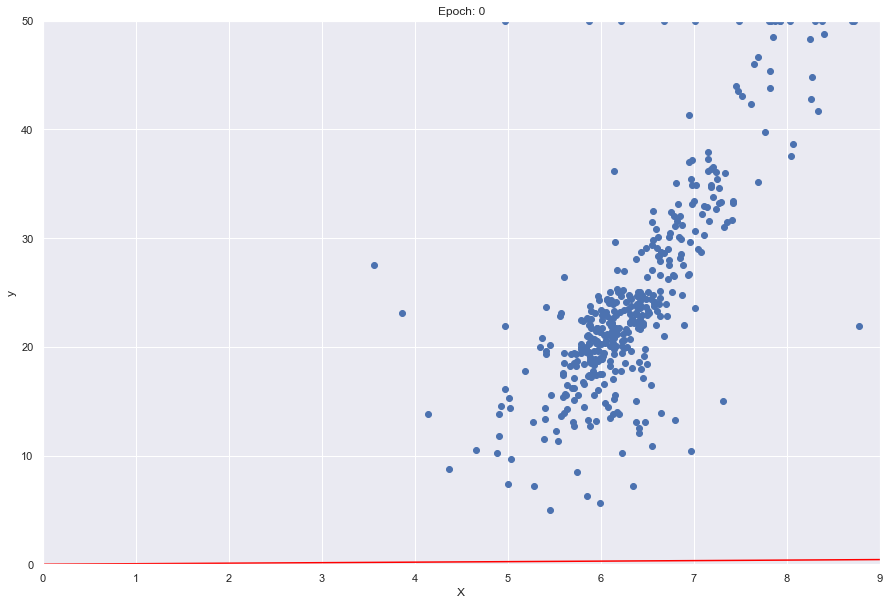

epoch:  5000 average loss:  52.65377484035674


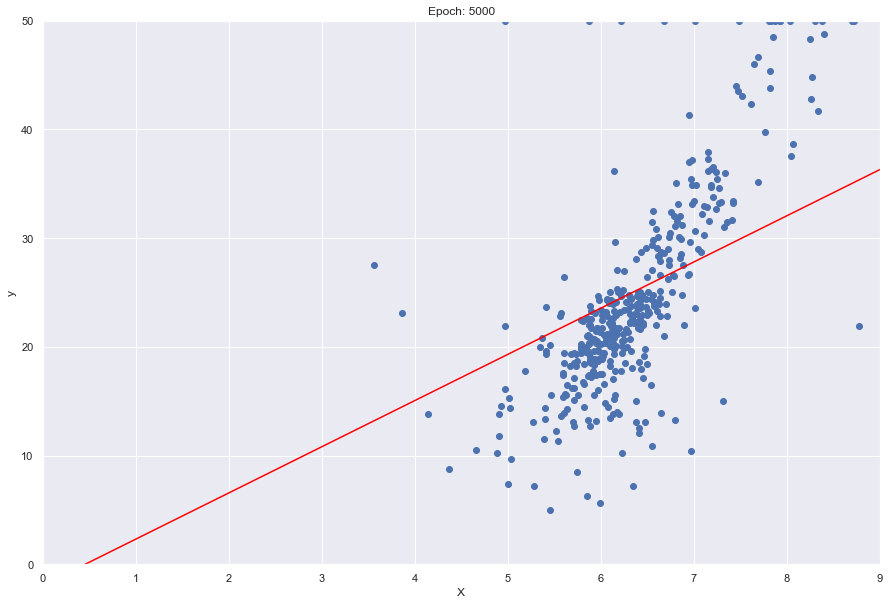

epoch:  10000 average loss:  50.39926830443642


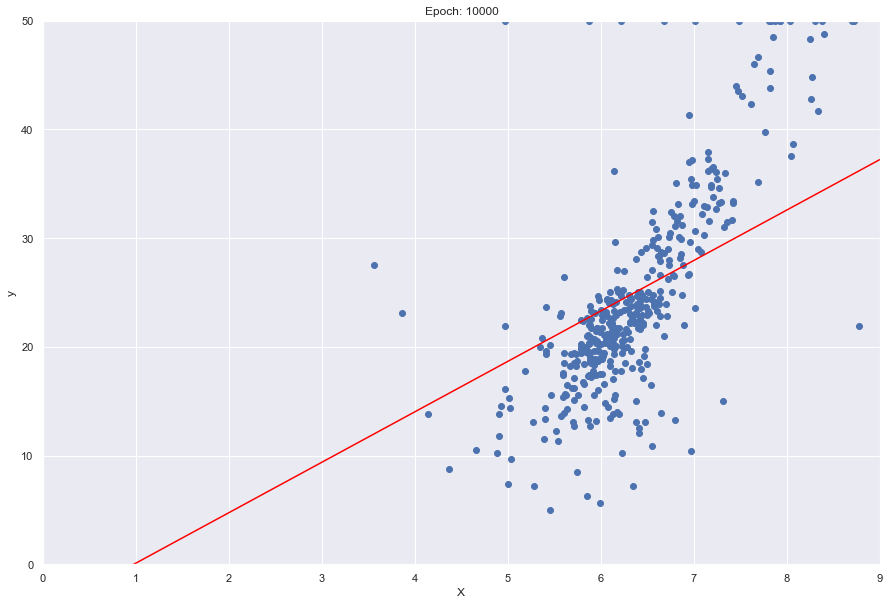

epoch:  15000 average loss:  49.040387658624404


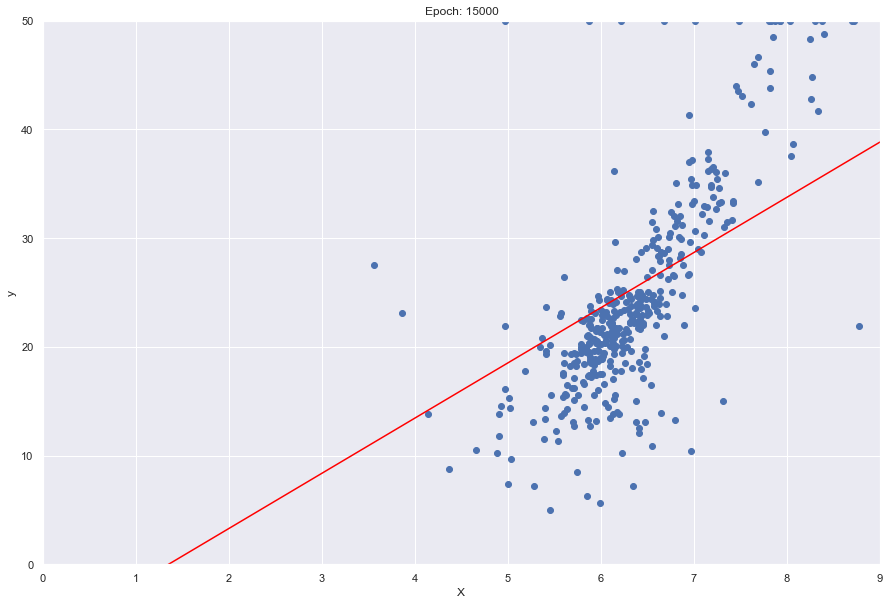

epoch:  20000 average loss:  47.04233570662692


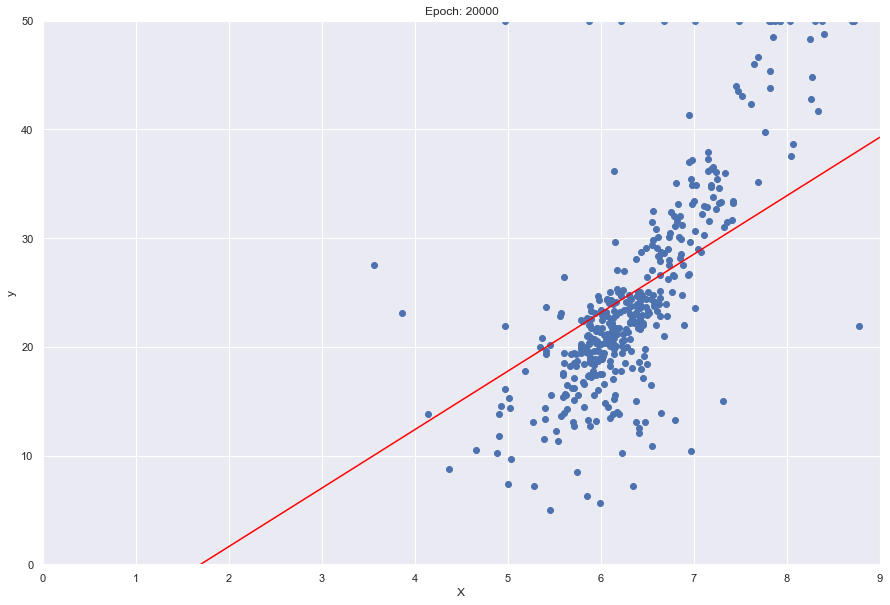

epoch:  25000 average loss:  45.61702912843982


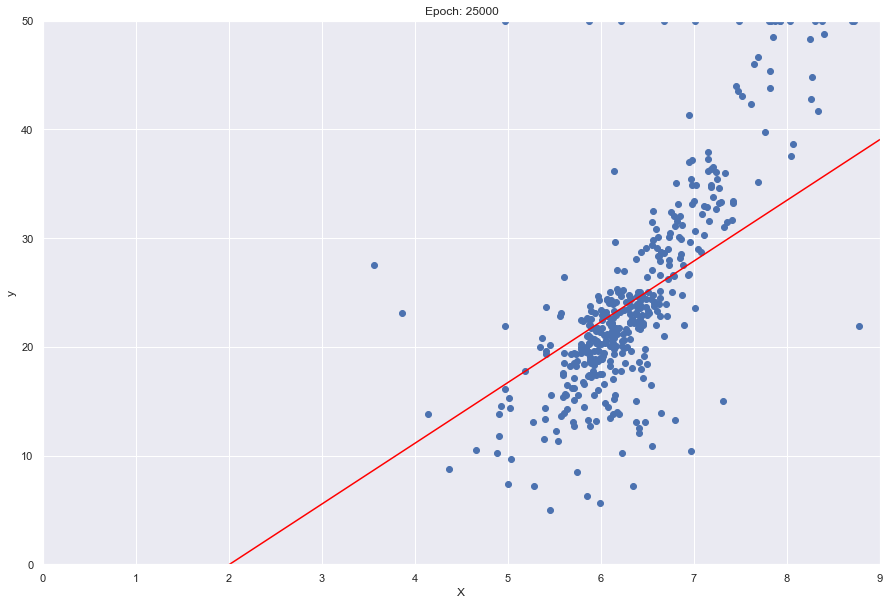

epoch:  30000 average loss:  44.29770762354117


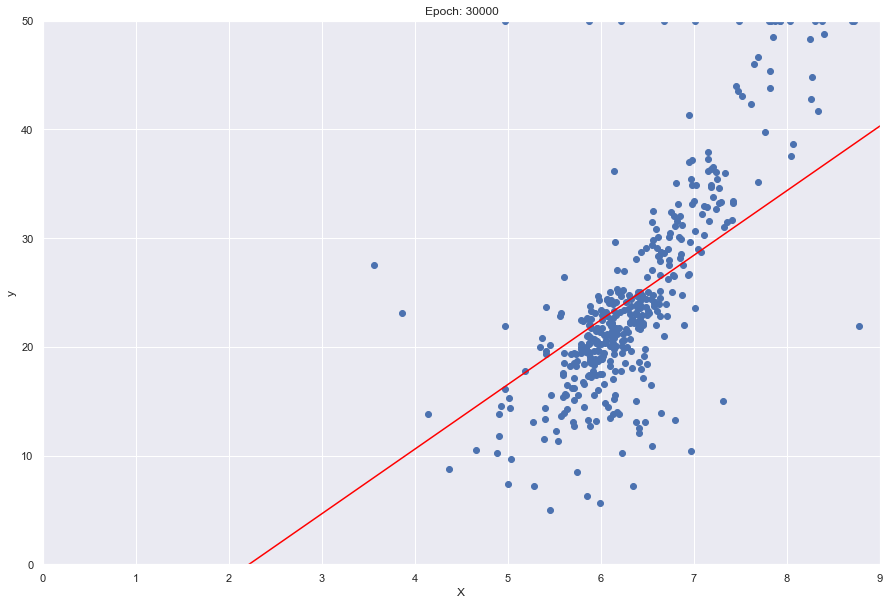

epoch:  35000 average loss:  43.43158440946043


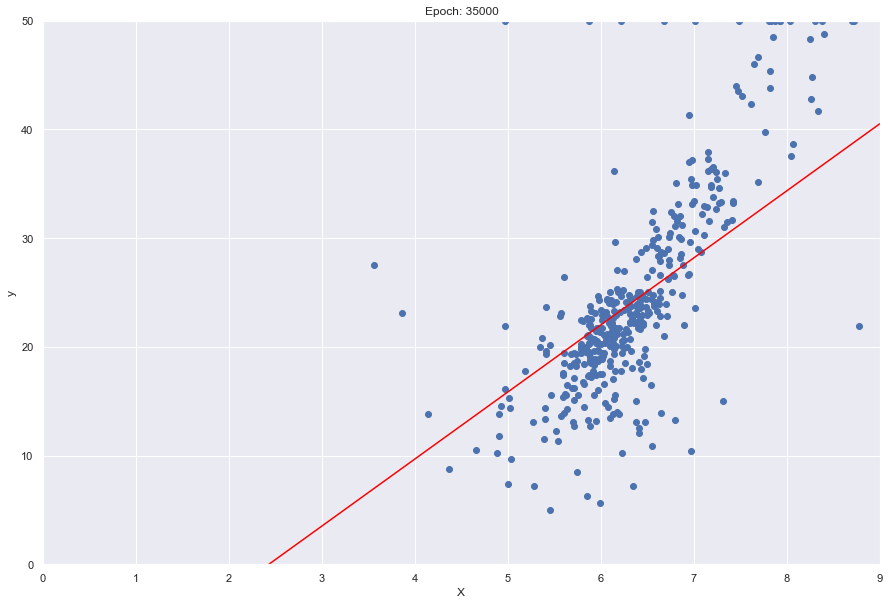

epoch:  40000 average loss:  42.47610956764854


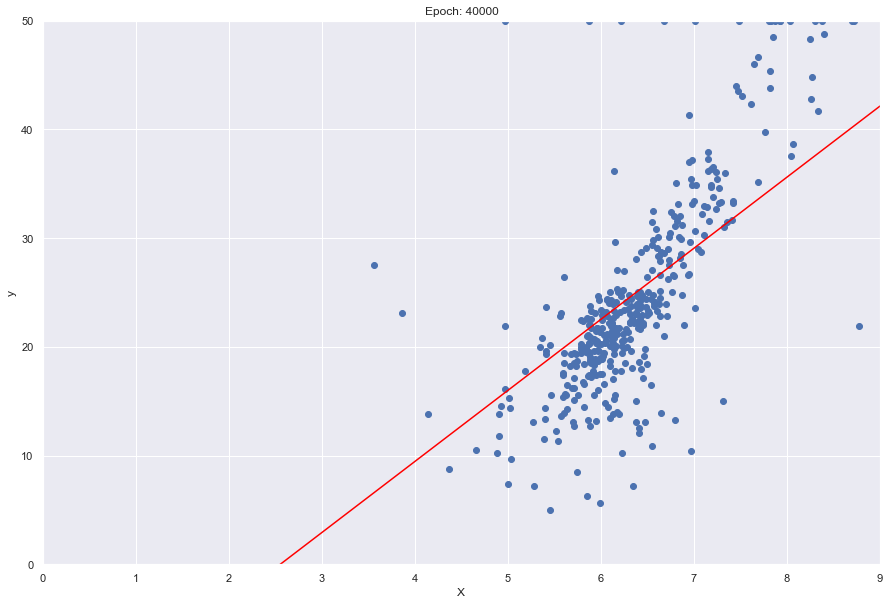

epoch:  45000 average loss:  41.66052336158605


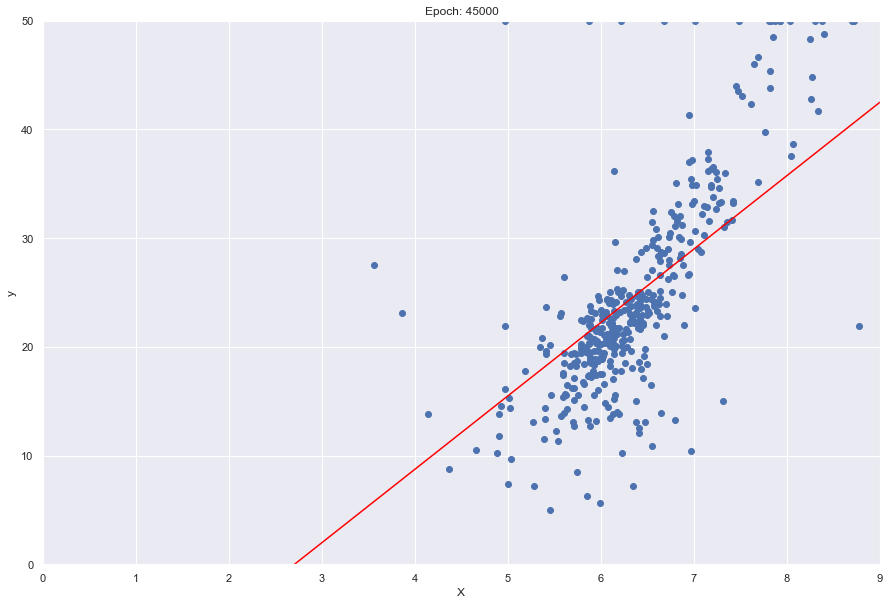

epoch:  50000 average loss:  40.99548163512693


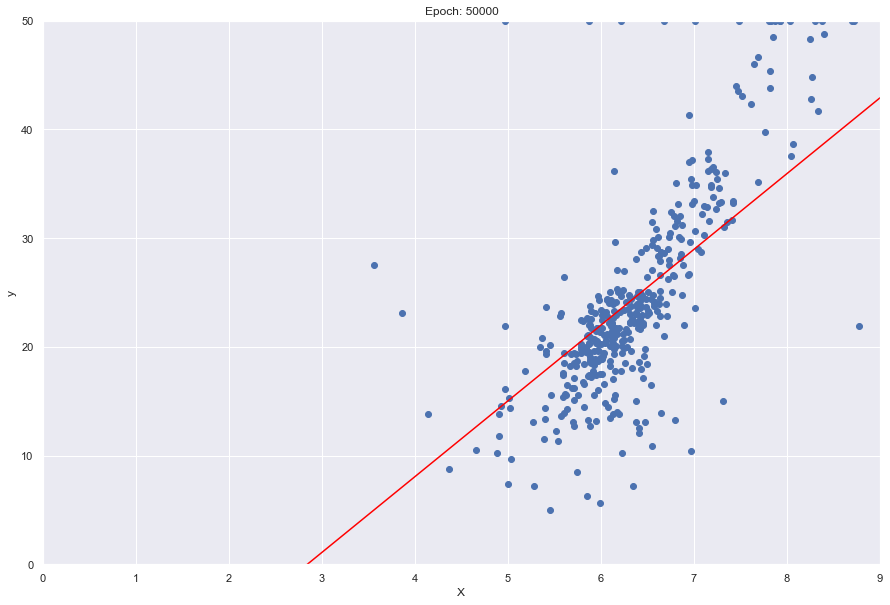

epoch:  55000 average loss:  40.51887172455033


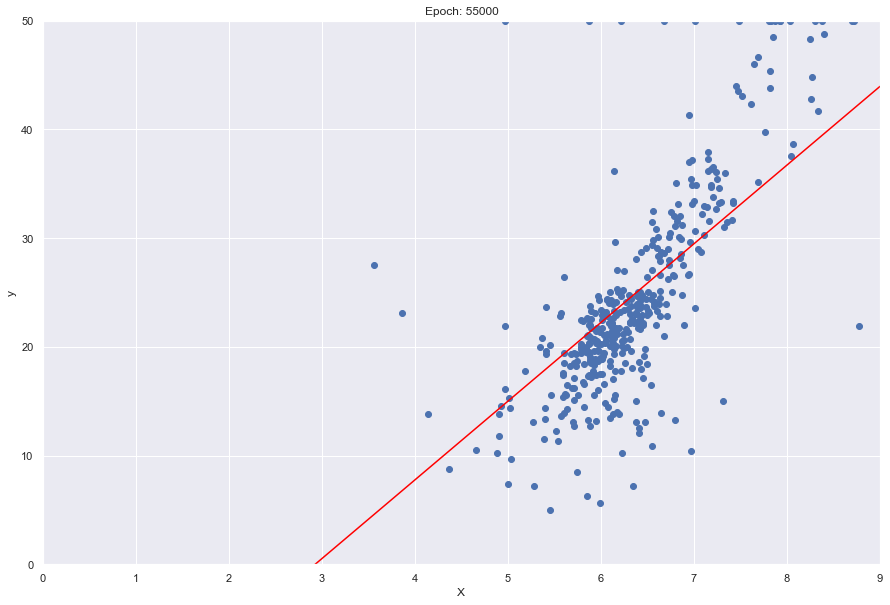

epoch:  60000 average loss:  40.14613067242878


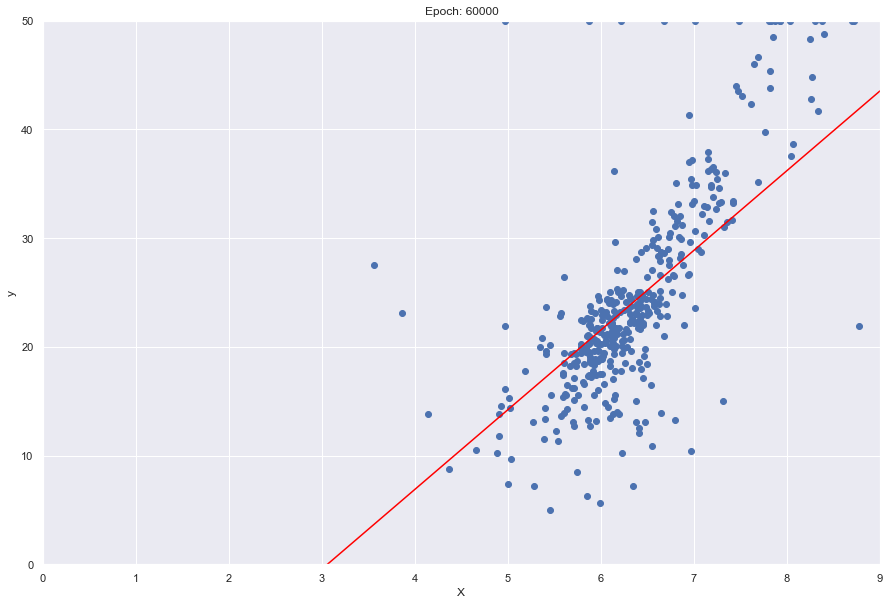

epoch:  65000 average loss:  39.767297231401805


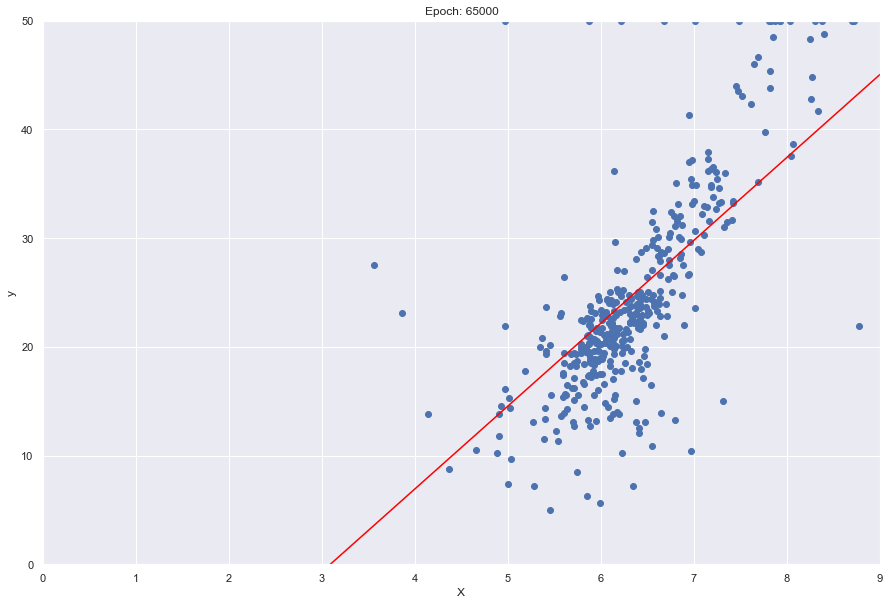

epoch:  70000 average loss:  39.33125075791881


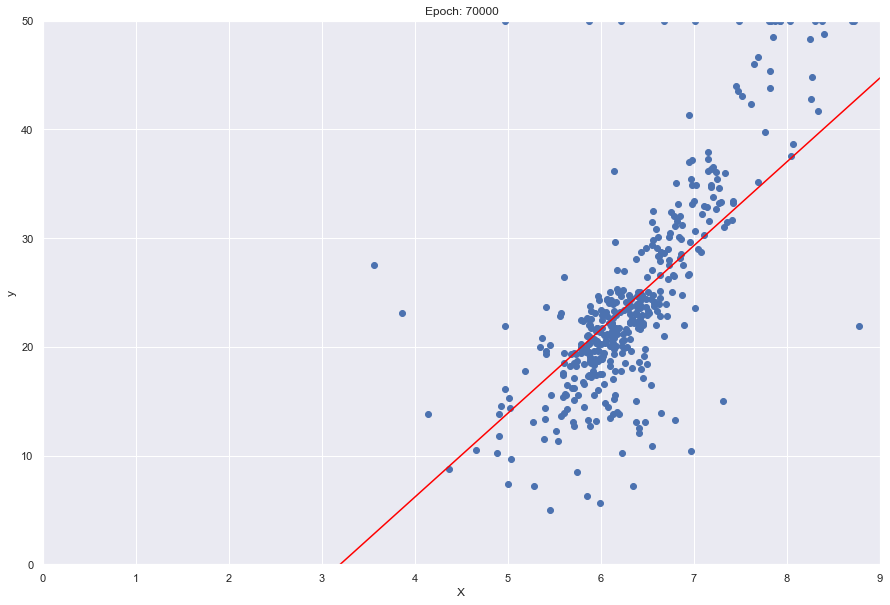

epoch:  75000 average loss:  39.03749637268615


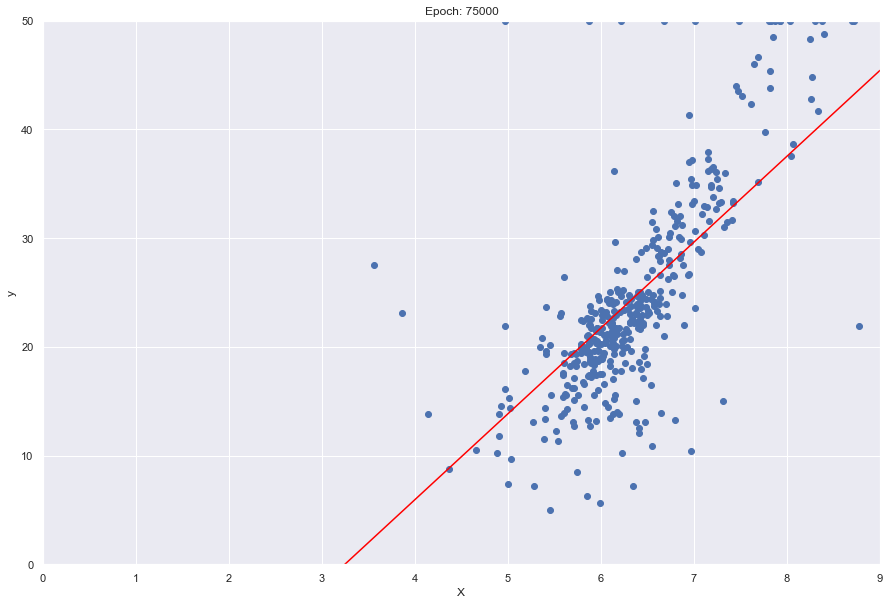

epoch:  80000 average loss:  38.84263379240864


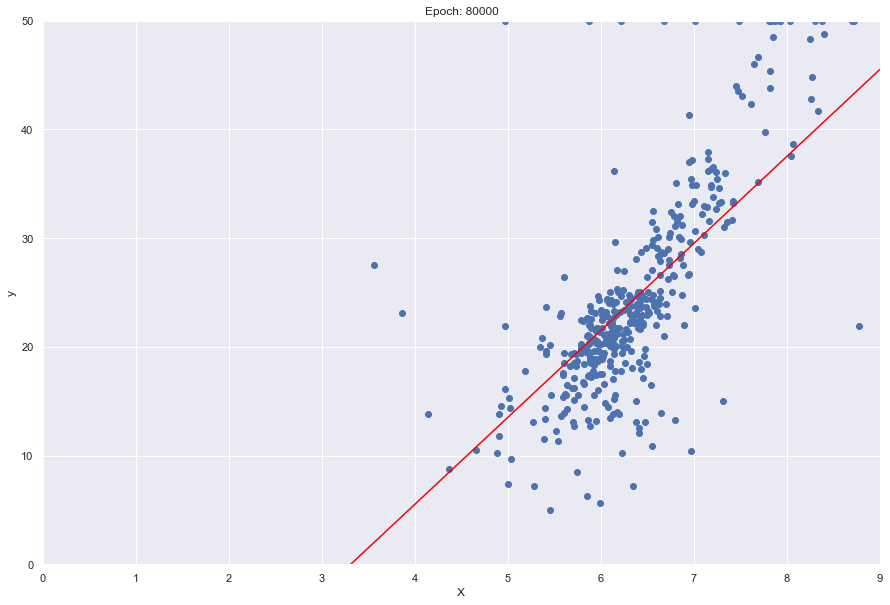

epoch:  85000 average loss:  38.89676481561059


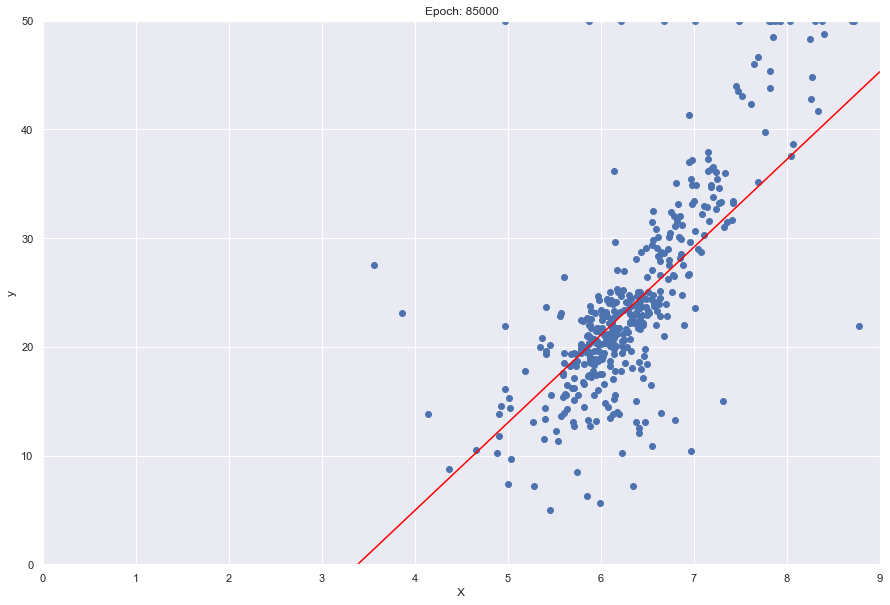

epoch:  90000 average loss:  38.62178350259429


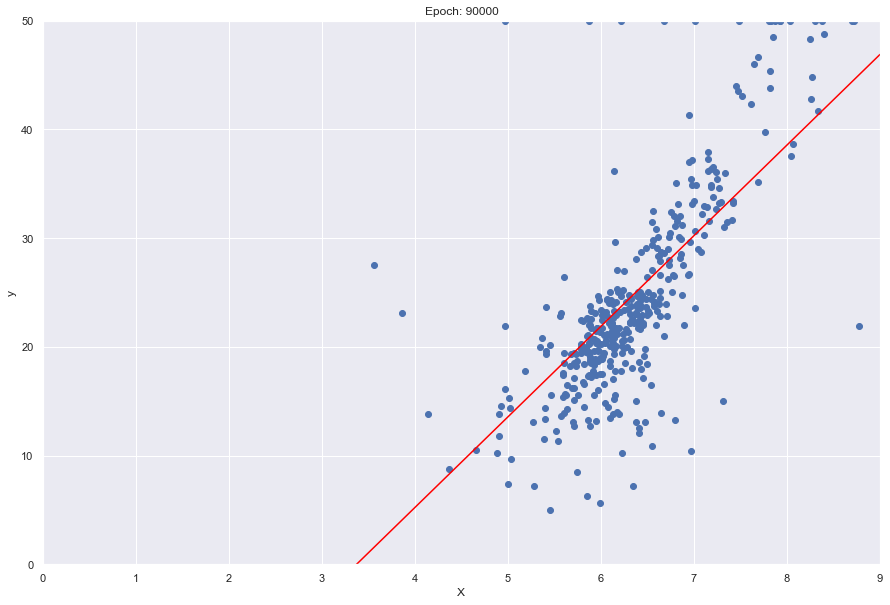

epoch:  95000 average loss:  38.42128807462251


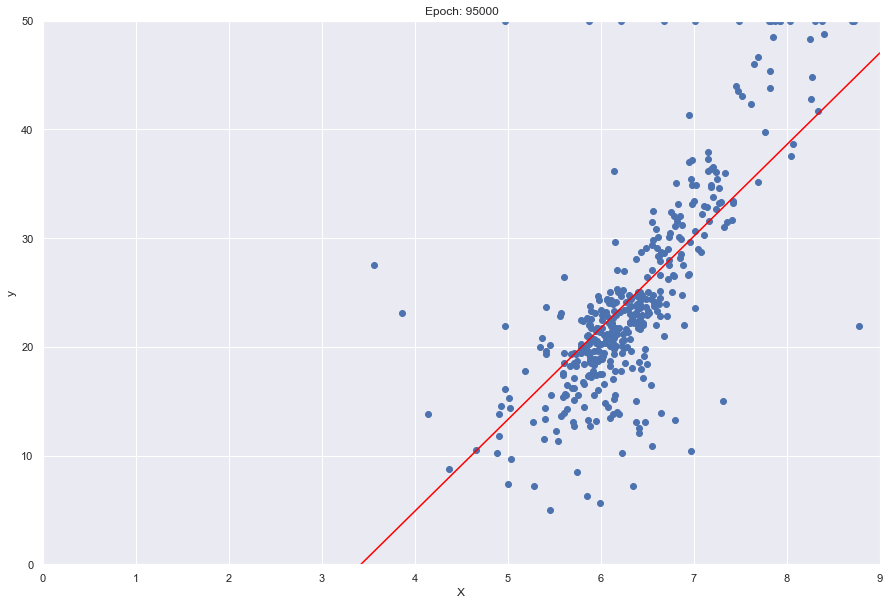

In [196]:
w_list,b_list, avg_loss_list, w, b, img_list, pred_val_at_diff_epoch = train(df["RM"][0:403], df["MEDV"][0:403], 0, 0, 0.001, 100000)

In [197]:
print(len(w_list))
print(len(b_list))
print(len(avg_loss_list))
print("best value for w: ",w)
print("best value for b: ",b)
print(len(img_list))
print(len(pred_val_at_diff_epoch))

10000
10000
10000
best value for w:  8.436836411296113
best value for b:  -29.444130812542053
20
20


In [198]:
n = np.linspace(10, 100000, 10000, endpoint = True)
len(n)

10000

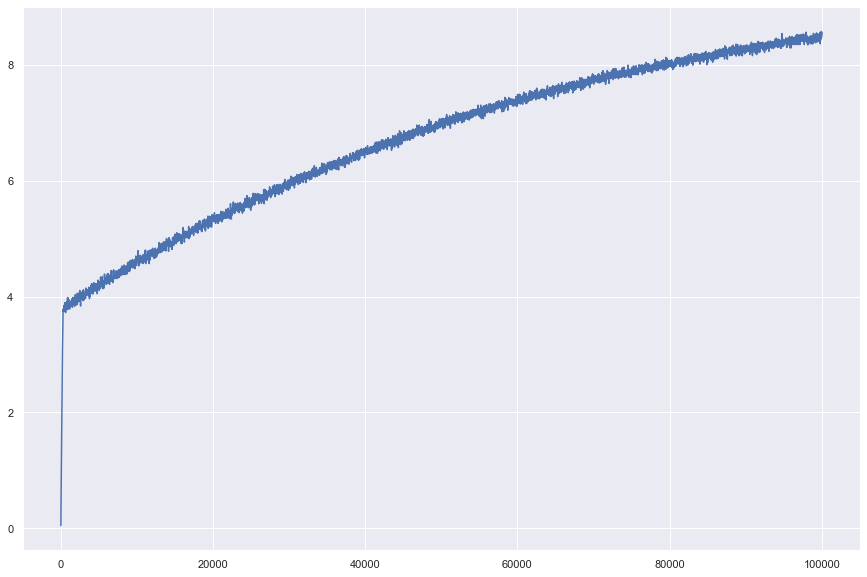

In [199]:
sns.set(rc = {"figure.figsize" : (15, 10)})
plt.plot(n, w_list)
plt.show()

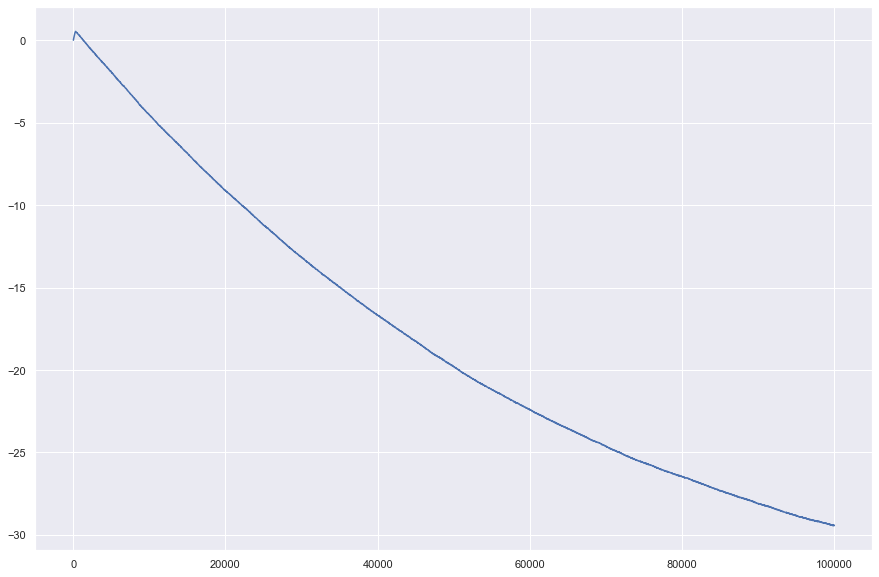

In [200]:
plt.plot(n, b_list)
plt.show()

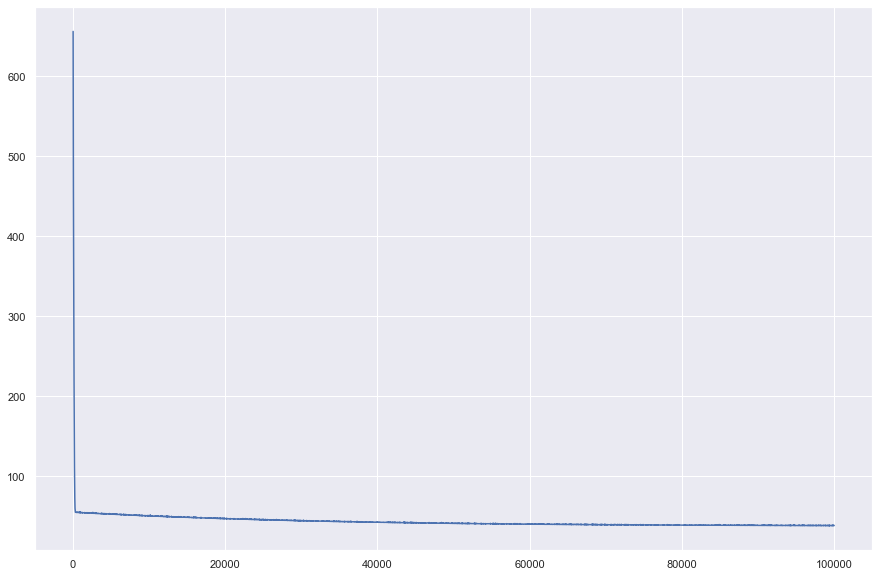

In [201]:
plt.plot(n, avg_loss_list)
plt.show()

In [202]:
predicted_vals = []
for feature in df["RM"]:
    predicted_vals.append(predict(feature, w, b))

In [203]:
predictedY_vs_realY = pd.DataFrame()

In [204]:
predictedY_vs_realY["REAL Y"] = df["MEDV"]
predictedY_vs_realY["PREDICTED Y"] = predicted_vals
predictedY_vs_realY["ERROR"] = abs(predictedY_vs_realY["REAL Y"] - predictedY_vs_realY["PREDICTED Y"])

In [205]:
predictedY_vs_realY.head()

,REAL Y,PREDICTED Y,ERROR
0,24.0,26.028069,2.028069
1,21.6,24.728796,3.128796
2,34.7,31.174539,3.525461
3,33.4,29.596850,3.803150
4,36.2,30.853939,5.346061


In [206]:
import imageio
with imageio.get_writer('gradient_descent_01.gif', mode='I') as writer:
    for filename in img_list:
        image = imageio.imread(filename)
        writer.append_data(image)